# Extract

# Import Library

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import os

# Load Dataset

In [2]:
project_dir = Path(r"C:\DWH_AirQuality_Health")

In [3]:
file_path = project_dir / "data_raw" / "Air_Quality_and_Health_Impacts_20260525.csv"

df = pd.read_csv(file_path)

df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,878239,386,Ozone (O3),Mean,ppb,UHF42,202,Downtown - Heights - Slope,Summer 2023,06/01/2023,33.868690,NaN
1,874488,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,302,Central Harlem - Morningside Heights,Summer 2023,06/01/2023,9.206519,NaN
2,876996,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Summer 2023,06/01/2023,12.068486,NaN
3,876915,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,301,Washington Heights,Summer 2023,06/01/2023,14.179620,NaN
4,878189,386,Ozone (O3),Mean,ppb,UHF34,302,Central Harlem - Morningside Heights,Summer 2023,06/01/2023,31.472151,NaN


In [4]:
print("\nINFORMASI DATASET")

print("Jumlah baris dan kolom:")
print(df.shape)


INFORMASI DATASET
Jumlah baris dan kolom:
(18862, 12)


In [5]:
print("\nINFO DATA ")
print(df.info())


INFO DATA 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB
None


In [6]:
print("\n NAMA KOLOM ")
print(df.columns.tolist())


 NAMA KOLOM 
['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info', 'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period', 'Start_Date', 'Data Value', 'Message']


# Cleaning

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nNAMA KOLOM SETELAH CLEANING ")
print(df.columns.tolist())


NAMA KOLOM SETELAH CLEANING 
['unique_id', 'indicator_id', 'name', 'measure', 'measure_info', 'geo_type_name', 'geo_join_id', 'geo_place_name', 'time_period', 'start_date', 'data_value', 'message']


In [8]:
df.head()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value,message
0,878239,386,Ozone (O3),Mean,ppb,UHF42,202,Downtown - Heights - Slope,Summer 2023,06/01/2023,33.868690,NaN
1,874488,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,302,Central Harlem - Morningside Heights,Summer 2023,06/01/2023,9.206519,NaN
2,876996,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,104,Pelham - Throgs Neck,Summer 2023,06/01/2023,12.068486,NaN
3,876915,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,301,Washington Heights,Summer 2023,06/01/2023,14.179620,NaN
4,878189,386,Ozone (O3),Mean,ppb,UHF34,302,Central Harlem - Morningside Heights,Summer 2023,06/01/2023,31.472151,NaN


# Membuat Folder Output

In [9]:
folders = [
    "data_clean",
    "data_batch",
    "output"
]

for folder in folders:
    os.makedirs(
        project_dir / folder,
        exist_ok=True
    )

# Membuat Data Batch

In [10]:
df["start_date"] = pd.to_datetime(
    df["start_date"],
    errors="coerce"
)

df["year"] = df["start_date"].dt.year
df["month"] = df["start_date"].dt.month
df["quarter"] = df["start_date"].dt.quarter

years = sorted(df["year"].dropna().unique())
year_groups = np.array_split(years, 3)

batch_info = []

for i, group in enumerate(year_groups, start=1):
    start_year = int(min(group))
    end_year = int(max(group))
    
    batch = df[
        (df["year"] >= start_year) &
        (df["year"] <= end_year)
    ].copy()
    
    batch["batch_id"] = i
    
    batch_file = project_dir / "data_batch" / f"batch_{i}_{start_year}_{end_year}.csv"
    batch.to_csv(batch_file, index=False)
    
    batch_info.append({
        "batch_id": i,
        "batch_name": f"Batch {i}",
        "start_year": start_year,
        "end_year": end_year,
        "rows": len(batch),
        "file": str(batch_file)
    })

batch_summary = pd.DataFrame(batch_info)

batch_summary

,batch_id,batch_name,start_year,end_year,rows,file
0,1,Batch 1,2005,2012,6904,C:\DWH_AirQuality_Health\data_batch\batch_1_20...
1,2,Batch 2,2013,2018,6984,C:\DWH_AirQuality_Health\data_batch\batch_2_20...
2,3,Batch 3,2019,2023,4974,C:\DWH_AirQuality_Health\data_batch\batch_3_20...


# Reader

In [11]:
batch_list = []

for _, row in batch_summary.iterrows():
    batch_df = pd.read_csv(row["file"])
    batch_df["batch_id"] = row["batch_id"]
    batch_list.append(batch_df)

df = pd.concat(batch_list, ignore_index=True)

print("Jumlah data setelah proses reader/parser batch:")
print(df.shape)

df.head()

Jumlah data setelah proses reader/parser batch:
(18862, 16)


,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value,message,year,month,quarter,batch_id
0,166005,375,Nitrogen dioxide (NO2),Mean,ppb,CD,307,Sunset Park (CD7),Winter 2012-13,2012-12-01,25.99,NaN,2012,12,4,1
1,174262,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,303,East Harlem,Annual Average 2013,2012-12-01,9.73,NaN,2012,12,4,1
2,175455,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,501,Port Richmond,Winter 2012-13,2012-12-01,23.64,NaN,2012,12,4,1
3,175430,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,207,East Flatbush - Flatbush,Winter 2012-13,2012-12-01,25.91,NaN,2012,12,4,1
4,171716,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,403,Flushing - Clearview,Winter 2012-13,2012-12-01,22.06,NaN,2012,12,4,1


# Analisis Missing Value & Sparsity

In [12]:
print("\n ANALISIS MISSING VALUE ")

missing = df.isnull().sum()

missing_percent = (
    missing / len(df)
) * 100

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).sort_values(
    by="missing_percent",
    ascending=False
)

print(missing_table)


 ANALISIS MISSING VALUE 
                missing_count  missing_percent
message                 18862            100.0
unique_id                   0              0.0
name                        0              0.0
indicator_id                0              0.0
measure_info                0              0.0
geo_type_name               0              0.0
geo_join_id                 0              0.0
measure                     0              0.0
geo_place_name              0              0.0
time_period                 0              0.0
start_date                  0              0.0
data_value                  0              0.0
year                        0              0.0
month                       0              0.0
quarter                     0              0.0
batch_id                    0              0.0


In [13]:
total_cells = np.prod(df.shape)

missing_cells = df.isnull().sum().sum()

sparsity = (
    missing_cells / total_cells
) * 100

print(f"\nSparsity Dataset: {sparsity:.2f}%")


Sparsity Dataset: 6.25%


In [14]:
if sparsity < 5:

    print("Dataset memiliki sparsity rendah")

elif sparsity < 20:

    print("Dataset memiliki sparsity sedang")

else:

    print("Dataset memiliki sparsity tinggi")

Dataset memiliki sparsity sedang


# Analisis Duplikat & Imbalance

In [15]:
duplicate_count = df.duplicated().sum()

print(f"\nJumlah data duplikat: {duplicate_count}")


Jumlah data duplikat: 0


In [16]:
print("\nANALISIS IMBALANCE")

indicator_dist = df["name"].value_counts()

print(indicator_dist)

imbalance_ratio = (
    indicator_dist.max() /
    indicator_dist.min()
)

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")


ANALISIS IMBALANCE
name
Nitrogen dioxide (NO2)                                    6345
Fine particles (PM 2.5)                                   6345
Ozone (O3)                                                2115
Asthma hospitalizations due to Ozone                       480
Asthma emergency departments visits due to Ozone           480
Asthma emergency department visits due to PM2.5            480
Annual vehicle miles traveled                              321
Annual vehicle miles traveled (trucks)                     321
Annual vehicle miles traveled (cars)                       321
Cardiovascular hospitalizations due to PM2.5 (age 40+)     240
Respiratory hospitalizations due to PM2.5 (age 20+)        240
Cardiac and respiratory deaths due to Ozone                240
Deaths due to PM2.5                                        240
Outdoor Air Toxics - Formaldehyde                          203
Outdoor Air Toxics - Benzene                               203
Boiler Emissions- Total SO2 Em

In [17]:
if imbalance_ratio > 10:
    print("Dataset cenderung imbalanced")
else:
    print("Dataset relatif seimbang")

Dataset cenderung imbalanced


# Analisis Outlier

In [18]:
print("\n ANALISIS OUTLIER ")

numeric_col = "data_value"

# Pastikan numerik
df[numeric_col] = pd.to_numeric(
    df[numeric_col],
    errors="coerce"
)

Q1 = df[numeric_col].quantile(0.25)
Q3 = df[numeric_col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df[numeric_col] < lower_bound) |
    (df[numeric_col] > upper_bound)
]

print("Jumlah Outlier:", len(outliers))

print("\nBatas bawah:", lower_bound)
print("Batas atas :", upper_bound)


 ANALISIS OUTLIER 
Jumlah Outlier: 990

Batas bawah: -17.546239999999997
Batas atas : 52.55574399999999


In [19]:
outlier_percent = (
    len(outliers) / len(df)
) * 100

print("Jumlah Outlier:", len(outliers))
print(f"Persentase Outlier: {outlier_percent:.2f}%")

Jumlah Outlier: 990
Persentase Outlier: 5.25%


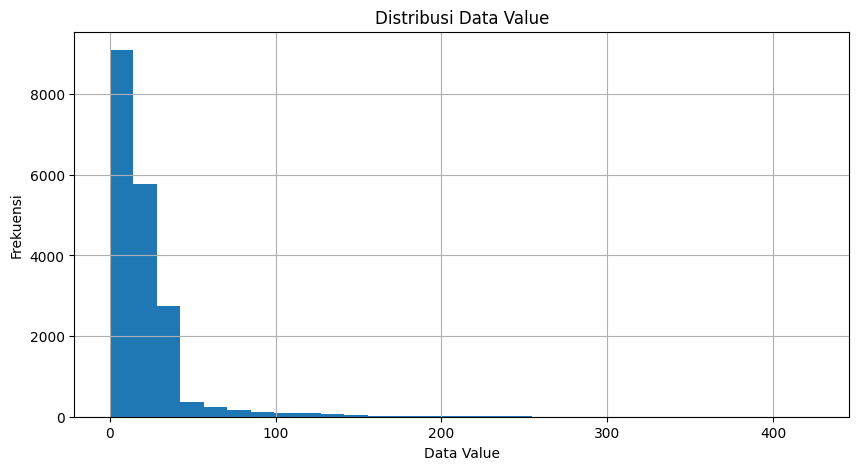

In [20]:
# VISUALISASI DISTRIBUSI DATA

plt.figure(figsize=(10, 5))

df["data_value"].hist(bins=30)

plt.title("Distribusi Data Value")
plt.xlabel("Data Value")
plt.ylabel("Frekuensi")

plt.show()

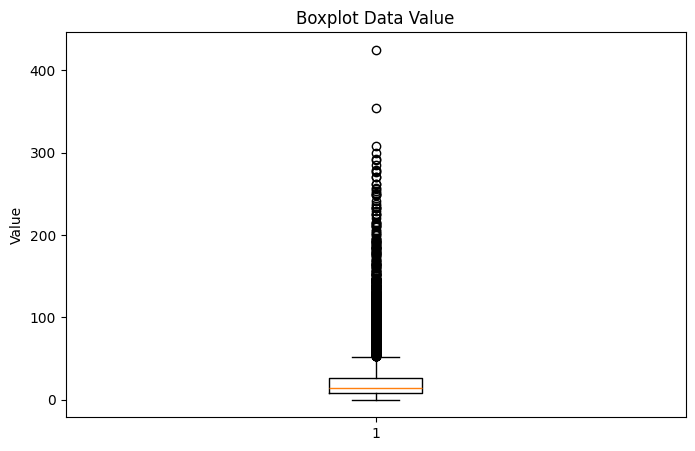

In [21]:
# VISUALISASI OUTLIER

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["data_value"].dropna()
)

plt.title("Boxplot Data Value")
plt.ylabel("Value")

plt.show()

# Distribusi Geo Type 


DISTRIBUSI GEO TYPE 
geo_type_name
UHF42       7392
CD          6844
UHF34       3570
Borough      880
Citywide     176
Name: count, dtype: int64


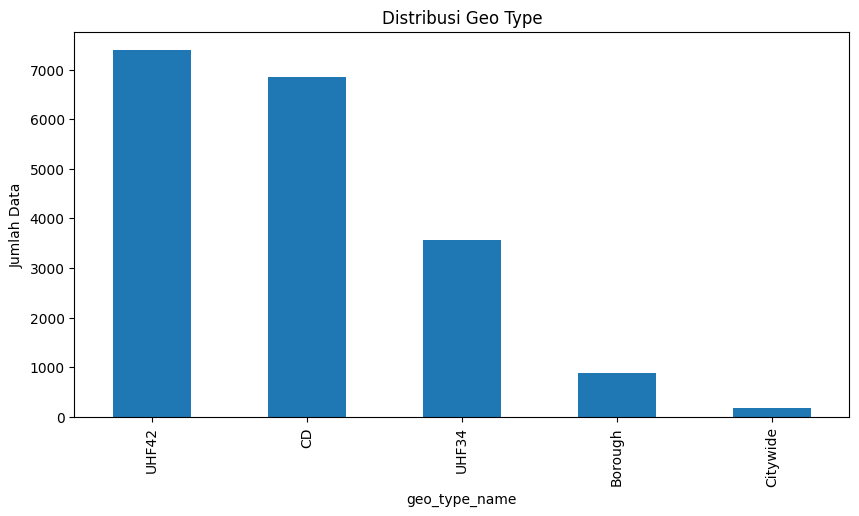

In [22]:
geo_dist = (
    df["geo_type_name"]
    .value_counts()
)

print("\nDISTRIBUSI GEO TYPE ")
print(geo_dist)

geo_dist.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribusi Geo Type")
plt.ylabel("Jumlah Data")

plt.show()

# Distribusi Tahunan


DISTRIBUSI TAHUN 
year
2005     897
2008     564
2009    1467
2010    1308
2011    1201
2012    1467
2013    1131
2014     801
2015    1893
2016     705
2017    1467
2018     987
2019    1308
2020     987
2021     987
2022     987
2023     705
Name: count, dtype: int64


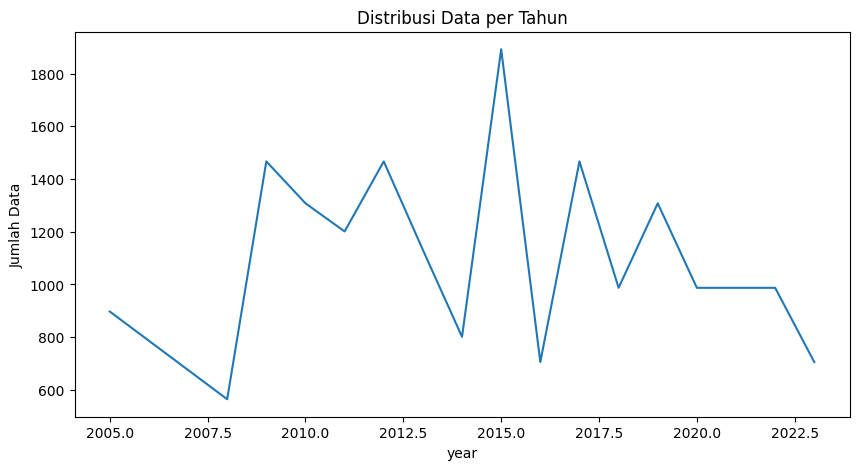

In [23]:
df["start_date"] = pd.to_datetime(
    df["start_date"],
    errors="coerce"
)

df["year"] = (
    df["start_date"]
    .dt.year
)

year_dist = (
    df["year"]
    .value_counts()
    .sort_index()
)

print("\nDISTRIBUSI TAHUN ")
print(year_dist)

year_dist.plot(figsize=(10, 5))

plt.title("Distribusi Data per Tahun")
plt.ylabel("Jumlah Data")

plt.show()

# Transform / Cleaning Data

In [24]:
df_clean = df.copy()

if "message" in df_clean.columns:
    df_clean = df_clean.drop(
        columns=["message"]
    )

df_clean = df_clean.drop_duplicates()

df_clean["start_date"] = pd.to_datetime(df_clean["start_date"], errors="coerce")
df_clean["data_value"] = pd.to_numeric(df_clean["data_value"], errors="coerce")

df_clean["year"] = df_clean["start_date"].dt.year
df_clean["month"] = df_clean["start_date"].dt.month
df_clean["quarter"] = df_clean["start_date"].dt.quarter

df_clean = df_clean.dropna(subset=["start_date", "data_value"])

df_clean.head()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value,year,month,quarter,batch_id
0,166005,375,Nitrogen dioxide (NO2),Mean,ppb,CD,307,Sunset Park (CD7),Winter 2012-13,2012-12-01,25.99,2012,12,4,1
1,174262,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,303,East Harlem,Annual Average 2013,2012-12-01,9.73,2012,12,4,1
2,175455,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,501,Port Richmond,Winter 2012-13,2012-12-01,23.64,2012,12,4,1
3,175430,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,207,East Flatbush - Flatbush,Winter 2012-13,2012-12-01,25.91,2012,12,4,1
4,171716,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,403,Flushing - Clearview,Winter 2012-13,2012-12-01,22.06,2012,12,4,1


In [25]:
print("\nJumlah data setelah cleaning:")
print(df_clean.shape)


Jumlah data setelah cleaning:
(18862, 15)


In [26]:
def categorize_indicator(indicator_name):
    indicator_name_lower = str(indicator_name).lower()
    
    health_keywords = [
        "asthma", "hospital", "emergency", "death", 
        "mortality", "cardiovascular", "respiratory"
    ]
    
    air_keywords = [
        "pm2.5", "fine particles", "ozone", "no2", 
        "nitrogen dioxide", "air pollution", "emissions"
    ]
    
    if any(keyword in indicator_name_lower for keyword in health_keywords):
        return "Health Impact Indicator"
    elif any(keyword in indicator_name_lower for keyword in air_keywords):
        return "Air Quality Indicator"
    else:
        return "Other Indicator"

df_clean["indicator_category"] = df_clean["name"].apply(categorize_indicator)

df_clean["indicator_category"].unique()

array(['Air Quality Indicator', 'Health Impact Indicator',
       'Other Indicator'], dtype=object)

In [27]:
clean_file = project_dir / "data_clean" / "air_quality_health_clean.csv"

df_clean.to_csv(clean_file, index=False)

print("Data clean berhasil disimpan di:", clean_file)

Data clean berhasil disimpan di: C:\DWH_AirQuality_Health\data_clean\air_quality_health_clean.csv


# Membuat Dimensi Data

In [28]:
dim_batch = batch_summary[[
    "batch_id",
    "batch_name",
    "start_year",
    "end_year",
    "rows"
]].copy()

dim_batch = dim_batch.rename(columns={
    "rows": "total_rows"
})

dim_batch["description"] = dim_batch.apply(
    lambda row: f"Ekstraksi periodik data tahun {row['start_year']} sampai {row['end_year']}",
    axis=1
)

dim_batch

,batch_id,batch_name,start_year,end_year,total_rows,description
0,1,Batch 1,2005,2012,6904,Ekstraksi periodik data tahun 2005 sampai 2012
1,2,Batch 2,2013,2018,6984,Ekstraksi periodik data tahun 2013 sampai 2018
2,3,Batch 3,2019,2023,4974,Ekstraksi periodik data tahun 2019 sampai 2023


In [29]:
dim_time = (
    df_clean[["start_date", "year", "month", "quarter", "time_period"]]
    .drop_duplicates()
    .sort_values(["year", "month", "start_date"])
    .reset_index(drop=True)
)

dim_time.insert(0, "time_id", range(1, len(dim_time) + 1))

dim_time.head()

,time_id,start_date,year,month,quarter,time_period
0,1,2005-01-01,2005,1,1,2005
1,2,2005-01-01,2005,1,1,2005-2007
2,3,2008-12-01,2008,12,4,Annual Average 2009
3,4,2008-12-01,2008,12,4,Winter 2008-09
4,5,2009-01-01,2009,1,1,2009-2011


In [30]:
dim_location = (
    df_clean[["geo_type_name", "geo_join_id", "geo_place_name"]]
    .drop_duplicates()
    .sort_values(["geo_type_name", "geo_place_name"])
    .reset_index(drop=True)
)

dim_location.insert(0, "location_id", range(1, len(dim_location) + 1))

dim_location.head()

,location_id,geo_type_name,geo_join_id,geo_place_name
0,1,Borough,1,Bronx
1,2,Borough,2,Brooklyn
2,3,Borough,3,Manhattan
3,4,Borough,4,Queens
4,5,Borough,5,Staten Island


In [31]:
dim_indicator = (
    df_clean[["indicator_id", "name", "indicator_category"]]
    .drop_duplicates()
    .sort_values(["indicator_category", "name"])
    .reset_index(drop=True)
)

dim_indicator = dim_indicator.rename(columns={
    "indicator_id": "source_indicator_id",
    "name": "indicator_name"
})

dim_indicator.insert(0, "indicator_key", range(1, len(dim_indicator) + 1))

dim_indicator.head(50)

,indicator_key,source_indicator_id,indicator_name,indicator_category
0,1,642,Boiler Emissions- Total NOx Emissions,Air Quality Indicator
1,2,641,Boiler Emissions- Total PM2.5 Emissions,Air Quality Indicator
2,3,640,Boiler Emissions- Total SO2 Emissions,Air Quality Indicator
3,4,365,Fine particles (PM 2.5),Air Quality Indicator
4,5,375,Nitrogen dioxide (NO2),Air Quality Indicator
5,6,386,Ozone (O3),Air Quality Indicator
6,7,648,Asthma emergency department visits due to PM2.5,Health Impact Indicator
7,8,657,Asthma emergency department visits due to PM2.5,Health Impact Indicator
8,9,653,Asthma emergency departments visits due to Ozone,Health Impact Indicator
9,10,659,Asthma emergency departments visits due to Ozone,Health Impact Indicator


# Membuat Fact Tabel

In [32]:
fact = df_clean.merge(
    dim_time,
    on=["start_date", "year", "month", "quarter", "time_period"],
    how="left"
)

fact = fact.merge(
    dim_location,
    on=["geo_type_name", "geo_join_id", "geo_place_name"],
    how="left"
)

fact = fact.merge(
    dim_indicator,
    left_on=["indicator_id", "name", "indicator_category"],
    right_on=["source_indicator_id", "indicator_name", "indicator_category"],
    how="left"
)

fact_air_quality_health = fact[[
    "unique_id",
    "time_id",
    "location_id",
    "indicator_key",
    "batch_id",
    "data_value"
]].copy()

fact_air_quality_health.insert(0, "fact_id", range(1, len(fact_air_quality_health) + 1))

fact_air_quality_health.head()

,fact_id,unique_id,time_id,location_id,indicator_key,batch_id,data_value
0,1,166005,19,57,5,1,25.99
1,2,174262,20,76,4,1,9.73
2,3,175455,19,127,5,1,23.64
3,4,175430,19,110,5,1,25.91
4,5,171716,19,78,5,1,22.06


In [33]:
fact_air_quality_health.isnull().sum()

fact_id          0
unique_id        0
time_id          0
location_id      0
indicator_key    0
batch_id         0
data_value       0
dtype: int64

In [34]:
dim_time.to_csv(project_dir / "output" / "dim_time.csv", index=False)
dim_location.to_csv(project_dir / "output" / "dim_location.csv", index=False)
dim_indicator.to_csv(project_dir / "output" / "dim_indicator.csv", index=False)
dim_batch.to_csv(project_dir / "output" / "dim_batch.csv", index=False)
fact_air_quality_health.to_csv(project_dir / "output" / "fact_air_quality_health.csv", index=False)

print("Star schema berhasil disimpan.")

Star schema berhasil disimpan.


In [35]:
os.listdir(project_dir / "output")

['dim_batch.csv',
 'dim_indicator.csv',
 'dim_location.csv',
 'dim_time.csv',
 'fact_air_quality_health.csv']

# LOAD

# Connect postgreSQL

In [36]:
!pip install psycopg2-binary sqlalchemy pandas


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from sqlalchemy import create_engine

username = "postgres"
password = "adistiebil123"
host = "localhost"
port = "5432"
database = "dwh_air_quality"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

In [41]:
dim_time.to_sql(
    "dim_time",
    engine,
    if_exists="replace",
    index=False
)

dim_location.to_sql(
    "dim_location",
    engine,
    if_exists="replace",
    index=False
)

dim_indicator.to_sql(
    "dim_indicator",
    engine,
    if_exists="replace",
    index=False
)

dim_batch.to_sql(
    "dim_batch",
    engine,
    if_exists="replace",
    index=False
)

fact_air_quality_health.to_sql(
    "fact_air_quality_health",
    engine,
    if_exists="replace",
    index=False
)

print("Semua tabel berhasil di-load ke PostgreSQL")

Semua tabel berhasil di-load ke PostgreSQL


In [42]:
for table in [
    "dim_time",
    "dim_location",
    "dim_indicator",
    "dim_batch",
    "fact_air_quality_health"
]:
    result = pd.read_sql(
        f"SELECT COUNT(*) AS total_rows FROM {table};",
        engine
    )
    
    print(table, ":", result["total_rows"].iloc[0])

dim_time : 57
dim_location : 141
dim_indicator : 21
dim_batch : 3
fact_air_quality_health : 18862
